In [1]:
# SET 1 – K-Nearest Neighbor (KNN)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [15]:
# 1. Load the dataset and display shape and column names.

df = pd.read_csv('iris.csv')
print("Shape of the dataset:", df.shape)
print("Column names:", df.columns.tolist())


Shape of the dataset: (150, 6)
Column names: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [16]:
# 2. Display first 5 records.

print("First 5 records:")
print(df.head(5))


First 5 records:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [17]:
# 3. Check for missing values.
print("Missing values:")
print(df.isnull().sum())

Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [18]:
# 4. Split dataset into features and target.

X = df.drop(['Species' , 'Id'], axis=1)
y = df['Species']


In [19]:
# 5. Split data into 80% training and 20% testing.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# 6. Apply KNN with K = 3.
model = KNeighborsClassifier(n_neighbors=3)


In [21]:
# 7. Predict test data.

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [22]:
# 8. Calculate accuracy score.
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)


Accuracy Score: 1.0


In [23]:
# 9. Display confusion matrix.
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [24]:
# 10. Predict species for a flower with values [5.1, 3.5, 1.4, 0.2].
pred = model.predict([[5.1, 3.5, 1.4, 0.2]])
print("Predicted species for [5.1, 3.5, 1.4, 0.2]:", pred[0])


Predicted species for [5.1, 3.5, 1.4, 0.2]: Iris-setosa


c:\Users\MITAN TANK\Desktop\Programs\Python\Regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# SET 2 – Decision Tree Classifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
# 1. Load dataset and display summary.
df = pd.read_csv('wine.csv')
# df.info()
# or 
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,1.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,1.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,1.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,2.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,3.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,3.000000


In [ ]:
# 2. Display first 10 records.
print("First 10 records:")
print(df.head(10))


First 10 records:
   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   
5    14.20        1.76  2.45          15.2        112           3.27   
6    14.39        1.87  2.45          14.6         96           2.50   
7    14.06        2.15  2.61          17.6        121           2.60   
8    14.83        1.64  2.17          14.0         97           2.80   
9    13.86        1.35  2.27          16.0         98           2.98   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  

In [ ]:
# 3. Separate features and target.
X = df.drop('Customer_Segment', axis=1)  # Replace 'target' with the actual target column name
y = df['Customer_Segment']


In [ ]:
# 4. Split dataset into training and testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# 5. Apply Decision Tree Classifier (max_depth=4).
model = DecisionTreeClassifier(max_depth=4, random_state=42)


In [ ]:
# 6. Predict test data.
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [ ]:

# 7. Calculate accuracy.
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9444444444444444


In [ ]:

# 8. Display confusion matrix.
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[13  1  0]
 [ 0 14  0]
 [ 1  0  7]]


In [ ]:
# 9. Display classification report.
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           1       0.93      0.93      0.93        14
           2       0.93      1.00      0.97        14
           3       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.95      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



In [ ]:
# 10. Predict wine class for input sample values.
pred = model.predict([[13.0, 2.0, 2.5, 16.0, 100.0, 2.5, 1.5, 0.5, 1.0, 3.0, 1.0, 2.0, 100.0]])  # Replace with actual feature values
print("Predicted wine class for input sample values:", pred[0])


Predicted wine class for input sample values: 2


c:\Users\MITAN TANK\Desktop\Programs\Python\Regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [55]:
# SET 3 – Logistic Regression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [56]:
# 1. Load dataset and display info.
df = pd.read_csv('Titanic-Dataset.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [57]:
# 2. Handle missing values.
# Handle missing values using mean or median or mode.

df.fillna(df.mean(numeric_only=True), inplace=True)  # Fill numeric columns with mean


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C


In [58]:
# 3. Convert categorical columns (Sex) into numeric.
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


In [63]:
# 4. Select input features and target (Survived).
x = df.drop(['Survived' , 'PassengerId' , 'Name' , 'Ticket'], axis=1)  # Replace 'Survived' with the actual target column name
y = df['Survived']


In [64]:
# 5. Split the dataset into training and testing.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [65]:
# 6. Apply Logistic Regression.
model = LogisticRegression()


In [66]:
# 7. Predict test data.
model.fit(x_train, y_train)
y_pred = model.predict(x_test)


ValueError: could not convert string to float: 'C124'

In [67]:
# 8. Calculate accuracy.
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


ValueError: Found input variables with inconsistent numbers of samples: [179, 36]

In [68]:
# 8. Calculate accuracy.
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


ValueError: Found input variables with inconsistent numbers of samples: [179, 36]

In [69]:
# 9. Display confusion matrix.
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:


ValueError: Found input variables with inconsistent numbers of samples: [179, 36, 179]

In [70]:

# 10. Predict survival of a passenger (Age=30, Fare=50000, Sex=Male).
pred = model.predict([[30, 50000, 0]])  # Replace with actual feature values
print("Predicted survival for a passenger (Age=30, Fare=50000, Sex=Male):", pred[0])


c:\Users\MITAN TANK\Desktop\Programs\Python\Regression\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


AttributeError: 'LogisticRegression' object has no attribute 'coef_'

In [71]:
# SET 4 – Support Vector Machine (SVM)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [72]:
# 1. Load dataset and display columns.
df = pd.read_csv('Social_Network_Ads.csv')
print("Columns in the dataset:", df.columns.tolist())


Columns in the dataset: ['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased']


In [73]:

# 2. Select Age and EstimatedSalary as features.
X = df[['Age', 'EstimatedSalary']]


In [74]:
# 3. Select Purchased as target.
y = df['Purchased']  # Replace 'Purchased' with the actual target column name


In [75]:

# 4. Split the dataset into training and testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [76]:
# 5. Apply SVM (linear kernel).
model = SVC(kernel='linear', random_state=42)


In [ ]:
# 6. Predict test data.
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 7. Calculate accuracy.
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 8. Display confusion matrix.
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 9. Display classification report.
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 10. Predict purchase for (Age=35, Salary=60000).
pred = model.predict([[35, 60000]])  # Replace with actual feature values
print("Predicted purchase for (Age=35, Salary=60000):", pred[0])


In [1]:
# SET 5 – K-Means Clustering
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [4]:
# 1. Load dataset and display first 5 records.
df = pd.read_csv('Mall Customers.csv')
print("First 5 records:")
print(df.head())

First 5 records:
   CustomerID Gender  Age   Education  Marital Status  Annual Income (k$)  \
0           1      M   19  High School        Married                  15   
1           2      M   21     Graduate         Single                  15   
2           3      F   20     Graduate        Married                  16   
3           4      F   23  High School        Unknown                  16   
4           5      F   31   Uneducated        Married                  17   

   Spending Score (1-100)  
0                      39  
1                      81  
2                       6  
3                      77  
4                      40  


In [5]:
# 2. Select Annual Income and Spending Score.
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]  # Replace with actual column names


In [6]:
# 3. Apply K-Means clustering (K=5).
model = KMeans(n_clusters=5, random_state=42)
model.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [ ]:
# 4. Add a cluster column.
# df['Cluster'] = model.labels_
# or 
df['Cluster'] = model.predict(X)
print("Data with Cluster column:")


Data with Cluster column:


In [8]:
# 5. Display clustered data.
print(df.head())


   CustomerID Gender  Age   Education  Marital Status  Annual Income (k$)  \
0           1      M   19  High School        Married                  15   
1           2      M   21     Graduate         Single                  15   
2           3      F   20     Graduate        Married                  16   
3           4      F   23  High School        Unknown                  16   
4           5      F   31   Uneducated        Married                  17   

   Spending Score (1-100)  Cluster  
0                      39        4  
1                      81        2  
2                       6        4  
3                      77        2  
4                      40        4  


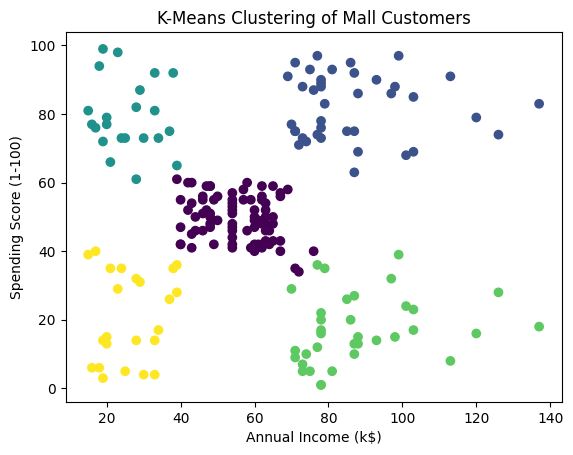

In [9]:

# 6. Plot clusters using scatter plot.
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'], cmap='viridis')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Clustering of Mall Customers')
plt.show()


In [10]:
# 7. Change K value and observe changes.
model = KMeans(n_clusters=3, random_state=42)
model.fit(X)
df['Cluster'] = model.predict(X)


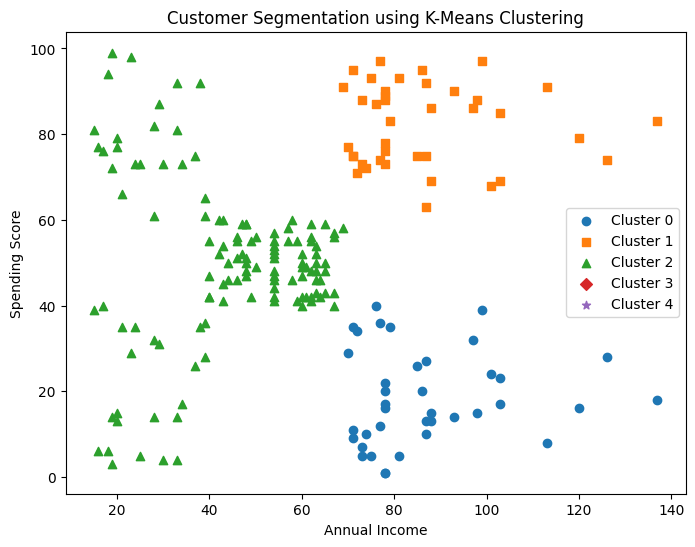

In [11]:
# 7. Change K value and observe changes.
model = KMeans(n_clusters=3, random_state=42)
model.fit(X)
df['Cluster'] = model.predict(X)

# 8. USe different markers for each cluster and plot a graph.
markers = ['o', 's', 'D', '^', 'v']
plt.figure(figsize=(8,6))

plt.scatter(df[df['Cluster']==0]['Annual Income (k$)'],
            df[df['Cluster']==0]['Spending Score (1-100)'],
            marker='o', label='Cluster 0')

plt.scatter(df[df['Cluster']==1]['Annual Income (k$)'],
            df[df['Cluster']==1]['Spending Score (1-100)'],
            marker='s', label='Cluster 1')

plt.scatter(df[df['Cluster']==2]['Annual Income (k$)'],
            df[df['Cluster']==2]['Spending Score (1-100)'],
            marker='^', label='Cluster 2')

plt.scatter(df[df['Cluster']==3]['Annual Income (k$)'],
            df[df['Cluster']==3]['Spending Score (1-100)'],
            marker='D', label='Cluster 3')

plt.scatter(df[df['Cluster']==4]['Annual Income (k$)'],
            df[df['Cluster']==4]['Spending Score (1-100)'],
            marker='*', label='Cluster 4')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means Clustering")

plt.legend()

plt.show()

In [12]:
#  SET 6 – Hierarchical Clustering
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

In [13]:
# 1. Load dataset and display summary.
df = pd.read_csv('Mall Customers.csv')
print("Summary of the dataset:")
print(df.describe())


Summary of the dataset:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


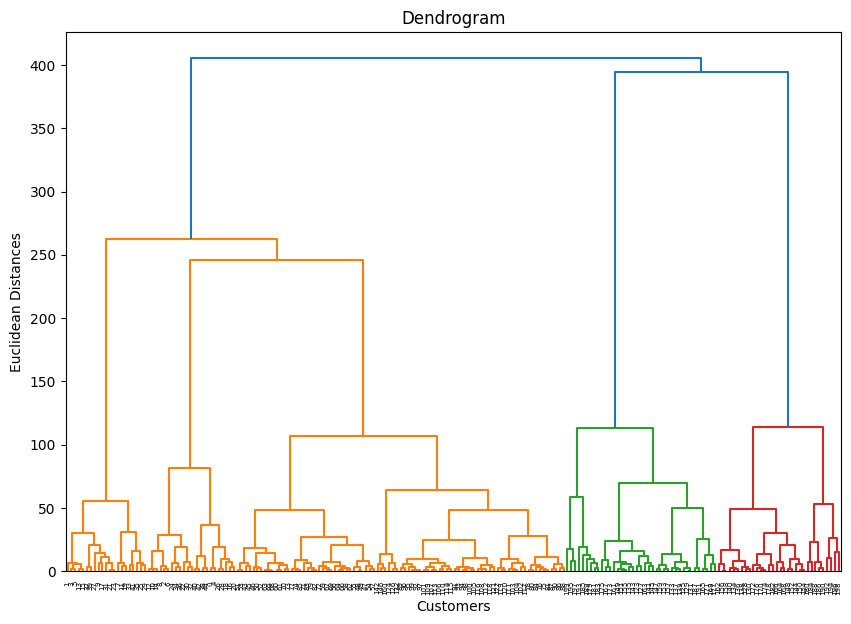

In [14]:
# 2. Select required features.
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]  # Replace with actual column names

# 3. Create a dendrogram.
plt.figure(figsize=(10, 7))
dend = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.show()


In [15]:
# 4. Determine the number of clusters.
n_clusters = 5

# 5. Apply Agglomerative Clustering.
model = AgglomerativeClustering(n_clusters=n_clusters)
clusters = model.fit_predict(X)


Clustered Data:
   CustomerID Gender  Age   Education  Marital Status  Annual Income (k$)  \
0           1      M   19  High School        Married                  15   
1           2      M   21     Graduate         Single                  15   
2           3      F   20     Graduate        Married                  16   
3           4      F   23  High School        Unknown                  16   
4           5      F   31   Uneducated        Married                  17   

   Spending Score (1-100)  Cluster  KMeans_Cluster  
0                      39        4               3  
1                      81        3               4  
2                       6        4               3  
3                      77        3               4  
4                      40        4               3  


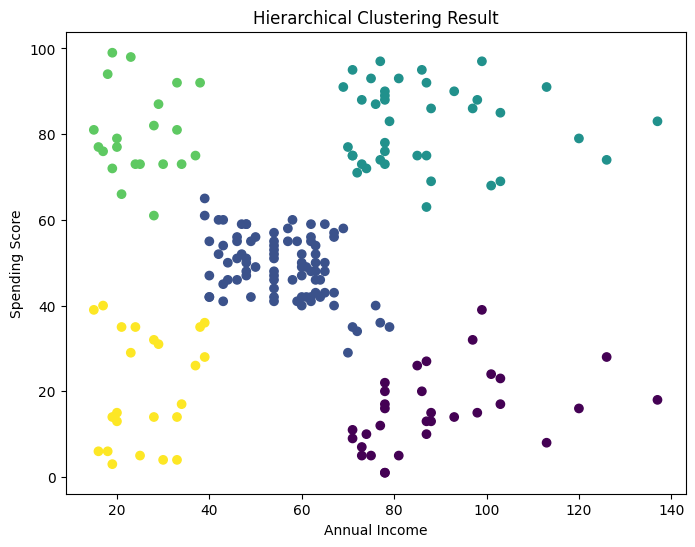

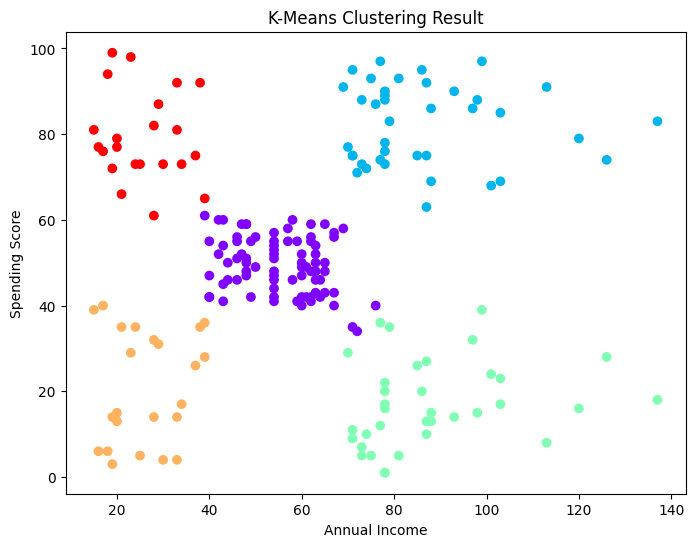

In [18]:
# 6. Add cluster column.
df['Cluster'] = clusters
print("\nClustered Data:")
print(df.head())

# 7. Plot clusters using scatter plot.
plt.figure(figsize=(8,6))

plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'], cmap='viridis')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Hierarchical Clustering Result")

plt.show()

# 8. Compare with K-Means result.
from sklearn.cluster import KMeans

# Apply K-Means
kmeans = KMeans(n_clusters=5, random_state=0)
k_clusters = kmeans.fit_predict(X)

# Add to dataframe
df['KMeans_Cluster'] = k_clusters


# Plot K-Means clusters
plt.figure(figsize=(8,6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['KMeans_Cluster'], cmap='rainbow')
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering Result")
plt.show()


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


In [21]:
# 1. Load dataset and display first 5 records.
df = pd.read_csv('Mall Customers.csv')
print("First 5 records:")
print(df.head())

First 5 records:
   CustomerID Gender  Age   Education  Marital Status  Annual Income (k$)  \
0           1      M   19  High School        Married                  15   
1           2      M   21     Graduate         Single                  15   
2           3      F   20     Graduate        Married                  16   
3           4      F   23  High School        Unknown                  16   
4           5      F   31   Uneducated        Married                  17   

   Spending Score (1-100)  
0                      39  
1                      81  
2                       6  
3                      77  
4                      40  


In [22]:
# 2. Select features for clustering.
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


In [24]:
# 3. Scale the data.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
